# ตอนที่ 2: SFT + LoRA — สอนโมเดลให้เป็นผู้ช่วย ด้วยการเทรน 1.69% ของพารามิเตอร์

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kobkrit/thai-llm-tutorials/blob/main/notebooks/02_sft_lora.ipynb)

โน้ตบุ๊กประกอบบทความ **[LLM 2/10] SFT + LoRA: สอนโมเดลให้เป็นผู้ช่วย ด้วยการเทรน 1.69% ของพารามิเตอร์**

โดย **ดร.กอบกฤตย์ วิริยะยุทธกร** — ผู้สร้าง OpenThaiGPT, CEO บริษัท iApp Technology
บทความฉบับเต็ม: [kobkrit.com](https://kobkrit.com/blog/llm-02-sft-lora)

---

## โครงของโน้ตบุ๊กนี้ (เรียงตรงกับหัวข้อในบทความ)

1. ปัญหา (Problem statement)
2. เราจะทำอะไร (Solution)
3. สมการ (Equation)
4. เห็นภาพสมการ (Visualize)
5. เตรียมสภาพแวดล้อม (Environment) — และวัด baseline ก่อนแตะอะไรทั้งสิ้น
6. เตรียมข้อมูล (Data)
7. โค้ดหลัก (Main code) — LoRA + completion mask พร้อม **assert จำนวนพารามิเตอร์กับเลขที่คำนวณด้วยมือ**
8. ผลลัพธ์ (Results)
9. เปรียบเทียบ (Comparison) — **การทดลองถอด mask ออก** ดาราของตอนนี้
10. สรุป (Summary)

---

## หัวใจของโน้ตบุ๊กนี้

หัวข้อที่ 7 มีบรรทัดนี้อยู่:

```python
assert n_train == EXPECTED_ADAPTER_PARAMS   # 10,092,544 -- คำนวณด้วยมือจากมิติจริงของโมเดล
```

บทความ LoRA แทบทุกชิ้นบอกให้ท่องว่า "เทรนต่ำกว่า 1% ของพารามิเตอร์"
โน้ตบุ๊กนี้ไม่ท่อง — มันคำนวณจำนวนพารามิเตอร์ adapter จากสมการ $r(d+k)$
กับมิติจริงใน config ของ Qwen3-0.6B แล้ว **assert กับตัวเลขที่ peft นับได้จริง**
(สปอยล์: 1.69% ไม่ใช่ "ต่ำกว่า 1%" — โมเดลเล็ก adapter เป็นสัดส่วนใหญ่กว่าที่บล็อกทั่วไปอ้าง)

และหัวข้อที่ 9 คือการทดลองที่ตั้งใจ **ทำพัง** ให้ดูกับตา: เทรนอีกรอบโดยไม่ใส่ completion mask
($m_t \equiv 1$) แล้วให้โมเดลทั้งสองตอบคำถามเดียวกัน — โมเดลที่ไม่ mask
จะ "ตอบเสร็จแล้วแต่งคำถามข้อถัดไปเอง" เพราะ gradient ส่วนใหญ่ของมันถูกใช้หัดเขียนคำถามผู้ใช้

---

## ก่อนเริ่ม

- โน้ตบุ๊กนี้ออกแบบมาให้รันได้บน **Google Colab แบบฟรี (Tesla T4)**
  เลือก `Runtime > Change runtime type > T4 GPU` ก่อนรันเซลล์แรก
- T4 เป็นสถาปัตยกรรม Turing (sm_75) ซึ่ง **ไม่รองรับ bfloat16 และไม่รองรับ FlashAttention-2**
  เราจึงกำหนด `torch_dtype=torch.float16`, `attn_implementation="sdpa"` และ `fp16=True` เอง
  อย่างชัดเจนทุกครั้ง (รายละเอียดอยู่ในคอมเมนต์ของ Cell 0 — อ่านให้ครบ)
- ทุกตอนในซีรีส์นี้ใช้ชุดวัดผลกลางตัวเดียวกันคือ `kobeval` และเบนช์มาร์ก **KobEval-TH**
  (120 ข้อ, 4 slice) เพื่อให้ตัวเลขของแต่ละตอนเทียบกันได้จริง
- **ห้ามเทรนบน KobEval-TH เด็ดขาด** ชุดนี้เป็นชุดวัดผลอย่างเดียว
  ข้อมูลที่ใช้เทรนในตอนนี้มาจาก `airesearch/wangchanx-seed-free-synthetic-instruct-thai-120k`
  ซึ่งแยกขาดจากชุดวัดผล
- adapter ที่เทรนเสร็จในตอนนี้ (`qwen3-0.6b-th-sft-lora`, ~40 MB) คือจุดตั้งต้นของ
  ตอนที่ 3 (RLHF/PPO) และตอนที่ 4 (DPO) — เซลล์ท้ายหัวข้อ 7 มีวิธี push ขึ้น Hugging Face Hub

## เวลาที่ใช้โดยประมาณบน T4 ฟรี (รวมเวลาโหลดโมเดล)

| ขั้นตอน | เวลาโดยประมาณ |
|---|---|
| Cell 0 ติดตั้ง dependencies | ~2 นาที |
| Cell 1 โหลดโมเดล + วัด baseline (TH-INSTR 30 ข้อ) | ~3 นาที |
| เตรียมข้อมูล 4,000 ตัวอย่าง | ~2 นาที |
| เทรน SFT แบบ mask (250 step) | ~9 นาที |
| เทรน ablation แบบไม่ mask (50 step) | ~2 นาที |
| วัดผลซ้ำ + generate ตัวอย่าง + กราฟ | ~5 นาที |
| **รวม** | **~20-23 นาที** |

ถ้า T4 ที่ได้ช้ากว่าปกติ ตั้ง `FAST_MODE = True` ใน Cell 1 —
จะลดข้อมูลเทรนเหลือ 2,000 ตัวอย่าง (~125 step) โน้ตบุ๊กเล่าเรื่องเดิมได้ครบ
เพียงแต่ขนาดของผลจะเล็กลง


In [ ]:
# =============================================================================
# CELL 0 -- SETUP
# ชุดนี้ต้อง "เหมือนกันทุกตัวอักษร" (byte-identical) ในโน้ตบุ๊กทั้ง 10 ตอน
# ตรวจสอบด้วย: python3 scripts/check_cell0.py
# =============================================================================
# ทำไมต้องเหมือนกันทุกตอน: ถ้า setup ต่างกันแม้นิดเดียว ตัวเลขที่วัดได้จาก
# แต่ละตอนจะเปรียบเทียบกันไม่ได้ ซึ่งทำให้ทั้งซีรีส์นี้ไร้ความหมาย
# -----------------------------------------------------------------------------

# 1) ติดตั้ง dependencies (pin เวอร์ชันไว้ทั้งหมด เพื่อให้ผลลัพธ์ทำซ้ำได้)
#    หมายเหตุ: เราจงใจ "ไม่" ติดตั้ง torch ใหม่ เพราะ Colab มี torch ที่ build
#    มาให้ตรงกับ CUDA driver อยู่แล้ว การ pip install torch ทับคือสาเหตุอันดับ
#    หนึ่งที่ทำให้ notebook พังบน Colab
!pip install -q \
    "transformers==4.51.3" \
    "accelerate==1.6.0" \
    "datasets==3.5.0" \
    "peft==0.15.1" \
    "trl==0.16.1" \
    "bitsandbytes==0.45.5" \
    "sentencepiece==0.2.0" \
    "matplotlib==3.10.1"

# 2) ติดตั้งฟอนต์ไทยให้ matplotlib (ไม่งั้นกราฟจะขึ้นเป็นสี่เหลี่ยม tofu)
!apt-get install -y fonts-thai-tlwg > /dev/null 2>&1

# 3) ดึง repo (ได้ทั้งแพ็กเกจ kobeval และชุดข้อมูล KobEval-TH)
import os
REPO_DIR = "/content/thai-llm-tutorials"
if not os.path.exists(REPO_DIR):
    !git clone -q https://github.com/kobkrit/thai-llm-tutorials.git /content/thai-llm-tutorials
!pip install -q -e /content/thai-llm-tutorials

# ลดการแตกกระจายของหน่วยความจำ (fragmentation) -- ต้องตั้งก่อน torch แตะ CUDA
# T4 มี VRAM จำกัด พอ tensor ก้อนใหญ่ถูกจอง/คืนสลับกัน จะเกิดช่องว่างที่ใช้ต่อไม่ได้
# จน OOM ทั้งที่ยังเหลือที่รวม ๆ อยู่ (ข้อความ error ของ PyTorch เองก็แนะนำค่านี้)
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

import random
import numpy as np
import torch

# 4) ยืนยันว่ามี GPU จริง -- ถ้าไม่มีให้หยุดตรงนี้เลย ดีกว่าไปพังตอน train
assert torch.cuda.is_available(), (
    "ไม่พบ GPU! ไปที่ Runtime > Change runtime type > Hardware accelerator > GPU "
    "แล้วรันเซลล์นี้ใหม่"
)

GPU_NAME = torch.cuda.get_device_name(0)
CAPABILITY = torch.cuda.get_device_capability(0)
VRAM_GB = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
# bf16 "แบบมีฮาร์ดแวร์รองรับจริง" เริ่มที่ Ampere (sm_80) ขึ้นไปเท่านั้น
#
# หมายเหตุสำคัญ: torch.cuda.is_bf16_supported() ตอบ True บน T4 (sm_75) ด้วย
# ตั้งแต่ torch รุ่นใหม่ ๆ เพราะมันนับ "การจำลอง (emulation)" ว่ารองรับด้วย
# ซึ่งช้ากว่า fp16 มากและไม่ใช่สิ่งที่เราต้องการ เราจึงเช็ค compute capability
# ตรง ๆ แทน -- นี่คือกับดักจริงที่เจอตอนรันบน Colab
NATIVE_BF16 = CAPABILITY[0] >= 8
SUPPORTS_BF16 = NATIVE_BF16          # ใช้ชื่อเดิมต่อได้ แต่ความหมายคือ "native"

print(f"GPU            : {GPU_NAME}")
print(f"Compute cap.   : sm_{CAPABILITY[0]}{CAPABILITY[1]}")
print(f"VRAM           : {VRAM_GB:.1f} GB")
print(f"SUPPORTS_BF16  : {SUPPORTS_BF16}   (native; torch บอกว่า "
      f"{torch.cuda.is_bf16_supported()} เพราะนับ emulation ด้วย)")
print(f"torch          : {torch.__version__}")

# -----------------------------------------------------------------------------
# 5) จุดสำคัญที่สุดของเซลล์นี้ -- อ่านให้ครบ
#
# ถ้าคุณได้ Tesla T4 (ซึ่งเป็นค่าปกติของ Colab ฟรี) คุณจะเห็น
#     SUPPORTS_BF16 : False   (native)
# ทั้งที่ torch.cuda.is_bf16_supported() ตอบ True -- อย่าเชื่อค่านั้น
#
# T4 เป็นสถาปัตยกรรม Turing (sm_75) ซึ่ง "ไม่รองรับ" สองอย่างนี้:
#   - bfloat16  -> ต้องใช้ float16 แทน
#   - FlashAttention-2 -> ต้องใช้ sdpa แทน
#
# กับดักที่คนเจอบ่อยที่สุด: config ของ Qwen3-0.6B ระบุ torch_dtype: bfloat16
# ไว้ในไฟล์ ดังนั้นถ้าเขียน torch_dtype="auto" transformers จะเชื่อ config
# แล้วโหลดเป็น bf16 บนการ์ดที่ไม่รองรับ ผลคือได้ NaN, loss ไม่ลด หรือ
# โมเดลพ่นข้อความมั่ว โดยไม่มี error ฟ้องให้เห็นเลย
#
# เราจึงกำหนดค่าพวกนี้เอง "อย่างชัดเจน" ทุกครั้ง ไม่พึ่ง auto
# -----------------------------------------------------------------------------
DTYPE = torch.bfloat16 if SUPPORTS_BF16 else torch.float16
ATTN_IMPL = "sdpa"          # ห้ามใช้ flash_attention_2 บน T4
USE_FP16 = not SUPPORTS_BF16  # ส่งเข้า TrainingArguments: fp16=USE_FP16, bf16=SUPPORTS_BF16

print(f"\n--> DTYPE      : {DTYPE}")
print(f"--> ATTN_IMPL  : {ATTN_IMPL}")
print(f"--> fp16={USE_FP16}, bf16={SUPPORTS_BF16}  (ใช้คู่นี้กับ TrainingArguments)")

# 6) ตั้ง seed ทุกตัวที่เกี่ยวข้อง เพื่อให้ผลลัพธ์ทำซ้ำได้
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# 7) import kobeval -- ชุดวัดผลกลางที่ใช้เหมือนกันทั้ง 10 ตอน
#    pip install -e ลงทะเบียนแพ็กเกจไว้แล้ว แต่ sys.path ของเคอร์เนลที่รันอยู่
#    อาจยังไม่เห็น จึงใส่ path ของ repo เข้าไปตรง ๆ กันพลาด (idempotent)
import sys
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

from kobeval import evaluate, compare, plot_before_after, th_ratio, wilson_ci
from kobeval import EVAL_CONTRACT, verify_checksums
from kobeval.plotting import use_thai_font

# 8) ตั้งฟอนต์ไทยให้ matplotlib "ครั้งเดียวตรงนี้" มีผลกับทุกกราฟในโน้ตบุ๊ก
#    ทำไมต้องมีขั้นตอนนี้: apt ติดตั้งฟอนต์ใน (2) หลังจาก matplotlib สร้าง
#    แคชรายชื่อฟอนต์ไปแล้ว มันจึงมองไม่เห็นฟอนต์ไทย และวาดออกมาเป็นกล่อง []
#    use_thai_font() จะสแกนดิสก์ใหม่แล้วลงทะเบียนฟอนต์ให้
_thai_font = use_thai_font()
print(f"Thai font      : {_thai_font or 'ไม่พบ! กราฟภาษาไทยจะเป็นกล่อง [] -- รัน apt-get ในข้อ (2) ใหม่'}")

print(f"\nkobeval contract: {EVAL_CONTRACT}")
print(f"KobEval-TH checksum ok: {verify_checksums()['ok']}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 95.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.7/354.7 kB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 411.0/411.0 kB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.4/336.4 kB 34.2 MB/s eta 0:00:00
   ━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/76.1 MB 197.5 MB/s eta 0:00:01

   ━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/76.1 MB 191.3 MB/s eta 0:00:01

   ━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/76.1 MB 191.3 MB/s eta 0:00:01

   ━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/76.1 MB 191.3 MB/s eta 0:00:01

   ━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/76.1 MB 191.3 MB/s eta 0:00:01

...

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done


  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done


  Building editable for kobeval (pyproject.toml) ... done


GPU            : Tesla T4
Compute cap.   : sm_75
VRAM           : 14.6 GB


SUPPORTS_BF16  : False   (native; torch บอกว่า True เพราะนับ emulation ด้วย)
torch          : 2.11.0+cu128

--> DTYPE      : torch.float16
--> ATTN_IMPL  : sdpa
--> fp16=True, bf16=False  (ใช้คู่นี้กับ TrainingArguments)
Thai font      : Loma

kobeval contract: {'do_sample': False, 'max_new_tokens': 256, 'enable_thinking': False, 'seed': 42, 'version': 'kobeval-th-v1'}
KobEval-TH checksum ok: True


---

## 1. ปัญหา (Problem statement)

เอาโมเดล base แท้ ๆ อย่าง `Qwen3-0.6B-Base` จากตอนที่แล้วมาพิมพ์ใส่ว่า
*"ช่วยแนะนำอาหารไทยให้หน่อยครับ"* สิ่งที่ได้กลับมามักไม่ใช่คำตอบ แต่เป็น **การเขียนต่อ** —
มันอาจแต่งคำถามเพิ่มอีกสามข้อ เขียนต่อเป็นบทความท่องเที่ยว หรือเปลี่ยนไปเป็นภาษาอังกฤษกลางทาง
เพราะสิ่งเดียวที่มันเคยถูกเทรนคือ "ข้อความแบบนี้บนอินเทอร์เน็ต มักตามด้วยอะไร"

ความสามารถในการ *ตอบ* — รับคำสั่ง ตอบตรงประเด็น แล้ว **หยุด** — ไม่ได้มากับ pretraining
มันมาจาก **SFT (Supervised Fine-Tuning)**: การเทรนต่อด้วยคู่ (คำสั่ง, คำตอบที่ดี)

แต่พอจะลงมือทำเองจะเจอปัญหาซ้อนสองชั้น:

| ชั้น | ปัญหา | ผลที่เกิด |
|---|---|---|
| 1 | full fine-tuning เทรนทุกพารามิเตอร์ | โมเดลใหม่ทั้งก้อน ~1.2 GB ต่อหนึ่งงาน และเสี่ยงลบความรู้จากตอนที่ 1 |
| 2 | ข้อมูล SFT ของโมเดลเป็นภาษาอังกฤษเป็นหลัก | ถามไทย คำตอบ **ไหลเป็นอังกฤษกลางประโยค** (ที่มาของ `th_ratio`) |

ตอนนี้แก้ทั้งสองชั้นพร้อมกัน: SFT ด้วยข้อมูลคำสั่งภาษาไทย และทำผ่าน **LoRA** แทน full fine-tuning

---

## 2. เราจะทำอะไร (Solution)

เทรน Qwen3-0.6B ด้วยคู่คำสั่ง-คำตอบภาษาไทย 4,000 ตัวอย่าง
ด้วย loss ตัวเดียวกับตอนที่ 1 เป๊ะ ๆ บวกของใหม่สองชิ้น:

1. **Completion mask** — คิด loss เฉพาะ token ฝั่ง *คำตอบ* ไม่คิดฝั่งคำถาม
2. **LoRA** — แช่แข็งน้ำหนักเดิมทั้งหมด แล้วเทรนเมทริกซ์เล็ก ๆ สองตัวที่วางทับแต่ละเลเยอร์แทน

> **แนวคิดหลักของตอนนี้:** คุณไม่ได้กำลังเทรนน้ำหนักโมเดล —
> คุณกำลังเทรน **"ส่วนแก้" (correction) อันดับต่ำ** ที่วางทับน้ำหนักเดิม
> นี่คือเหตุผลที่ adapter มีขนาดแค่ ~40 MB, เหตุผลที่เก็บ adapter ยี่สิบตัวสลับใช้บน base
> ตัวเดียวได้ และเหตุผลที่ reference model ของตอนที่ 3-4 มีต้นทุน VRAM เพิ่ม **ศูนย์ไบต์**

---

## 3. สมการ (Equation)

### 3.1 SFT loss กับ completion mask

$$
\mathcal{L}_{\text{SFT}}(\theta) = -\mathbb{E}_{(x,y)}\left[\sum_{t=1}^{|y|} m_t \log p_\theta(y_t \mid x, y_{<t})\right]
$$

$m_t \in \{0,1\}$ คือ **completion mask** — เป็น 1 เฉพาะ token ฝั่งคำตอบ และเป็น 0 บน token ของ prompt

ลองถอด $m_t$ ออก (ตั้ง $m_t \equiv 1$) สมการนี้จะกลายเป็น objective ของ CPT ในตอนที่ 1 ทันที
**SFT คือ CPT บนข้อความที่ถูกจัดฉากเป็นบทสนทนา บวกกับ mask หนึ่งตัว** — ไม่มีอะไรมากกว่านั้น
แต่ $m_t \equiv 1$ คือ default ที่พลาดกันง่ายที่สุด และในข้อมูลคำสั่งภาษาไทยทั่วไป
token ฝั่ง prompt กินราว 60% ของตัวอย่าง — แปลว่า gradient ส่วนใหญ่กำลัง
**สอนโมเดลให้หัดเขียนคำถามของผู้ใช้** ไม่ใช่หัดตอบ (พิสูจน์ในหัวข้อ 9)

### 3.2 LoRA: เทรนส่วนแก้ ไม่ใช่น้ำหนัก

$$
W' = W_0 + \Delta W = W_0 + \frac{\alpha}{r}\,B A
$$

- $W_0 \in \mathbb{R}^{d\times k}$ ถูกแช่แข็ง ไม่รับ gradient เลย
- $B \in \mathbb{R}^{d\times r}$, $A \in \mathbb{R}^{r\times k}$ คือเมทริกซ์ adapter ที่เทรนจริง ($r=16$, $\alpha=32$ ดังนั้น $\alpha/r = 2$)
- **$B$ ถูก initialize เป็นศูนย์** ดังนั้น $\Delta W = 0$ ณ step แรก — การเทรนออกตัวจาก base เป๊ะ ๆ
- ตัวหาร $r$ ใน $\alpha/r$ ทำให้ขนาด update ไม่ขึ้นกับ rank — กวาดหา $r$ ได้โดยไม่จูน lr ใหม่

### 3.3 สัดส่วนพารามิเตอร์ที่เทรน — ตัวเลขที่ต้องเช็ค ไม่ใช่ท่อง

ต่อเมทริกซ์ $d \times k$ หนึ่งตัว adapter มีพารามิเตอร์ $r(d+k)$ ตัว คิดเป็นสัดส่วน $\frac{r(d+k)}{dk}$

adapter โต *เชิงเส้น* กับ hidden size แต่พารามิเตอร์ฐานโต *กำลังสอง* —
ยิ่งโมเดลเล็ก adapter จึงยิ่งเป็นสัดส่วนที่ใหญ่ แทนค่าจริงของ Qwen3-0.6B
(hidden 1024, intermediate 3072, 28 เลเยอร์, ติด adapter ทั้ง 7 เมทริกซ์)
จะได้ **10,092,544 ตัว จากฐาน 596,049,920 ตัว = 1.69%** ไม่ใช่ "ต่ำกว่า 1%" ที่บล็อกชอบอ้าง
เซลล์ในหัวข้อ 4 คำนวณเลขนี้จาก config จริง และหัวข้อ 7 `assert` มันกับตัวเลขที่ peft นับได้


---

## 5. เตรียมสภาพแวดล้อม (Environment) — และวัด baseline

หลักการของทั้งซีรีส์: **วัดก่อนเสมอ**

เซลล์ถัดไปคือ Cell 1 ซึ่งวัดผลโมเดลตั้งต้นด้วย KobEval-TH ก่อนที่เราจะเทรนอะไรทั้งนั้น
สังเกตค่า `th_ratio` เป็นพิเศษ — SFT ด้วยข้อมูลไทยล้วน 4,000 ตัวอย่าง *ควร* ขยับตัวเลขนี้
ให้เห็นชัด และถ้าไม่ขยับ นั่นคือสัญญาณให้ไปไล่ดู mask กับ chat template ก่อนสิ่งอื่น

> **หมายเหตุเรื่องเวลา:** เรารัน KobEval-TH เฉพาะ slice `TH-INSTR` (30 ข้อ)
> เพราะ SFT ในตอนนี้แก้เรื่อง "ตอบตามที่สั่งและตอบเป็นภาษาไทย" ซึ่ง TH-INSTR วัดตรงที่สุด
> เพิ่ม slice อื่นใน `KOBEVAL_SLICES` ได้ถ้ามีเวลา — สัญญาการวัดผลเหมือนกันทุกประการ


In [ ]:
# =============================================================================
# CELL 1 -- BASELINE (วัดผลก่อนเทรน/ก่อนแก้อะไรทั้งสิ้น)
# เซลล์นี้เป็นเซลล์โค้ดที่สองของทุกตอนในซีรีส์
# =============================================================================
import gc
import json
import math
import time

from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_ID = "Qwen/Qwen3-0.6B"     # ตัว post-trained -- ตอนนี้เราแก้ "พฤติกรรม" ไม่ได้สอนความรู้
KOBEVAL_SLICES = ["TH-INSTR"]    # slice ที่ SFT ตอนนี้ตั้งใจขยับตรงที่สุด
DEV = "cuda:0"
FAST_MODE = False                # True = ลดข้อมูลเทรนลงครึ่งหนึ่ง ถ้า T4 ที่ได้ช้ากว่าปกติ

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=DTYPE,             # <-- ห้ามใช้ค่า auto เด็ดขาดบน T4 (ดูคอมเมนต์ Cell 0)
    attn_implementation=ATTN_IMPL, # <-- sdpa เท่านั้น
    device_map=DEV,
)
model.eval()

cfg = model.config
print(f"โหลดโมเดลแล้ว: {MODEL_ID}")
print(f"dtype จริงของ parameter: {next(model.parameters()).dtype}")
print(f"จำนวนพารามิเตอร์: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")
print("--- ค่าจริงจาก config ของ Qwen3-0.6B (ไม่ใช่ค่าที่จำมา) ---")
print(f"  hidden_size             : {cfg.hidden_size}")
print(f"  intermediate_size       : {cfg.intermediate_size}")
print(f"  num_hidden_layers       : {cfg.num_hidden_layers}")
print(f"  num_attention_heads     : {cfg.num_attention_heads}")
print(f"  num_key_value_heads     : {cfg.num_key_value_heads}")
print(f"  head_dim                : {getattr(cfg, 'head_dim', None)}")
print(f"  vocab_size              : {cfg.vocab_size}")

VRAM_AFTER_BASE = torch.cuda.memory_allocated() / (1024 ** 3)
print(f"\nVRAM ที่ใช้หลังโหลดโมเดลฐาน: {VRAM_AFTER_BASE:.3f} GB")

# รันเบนช์มาร์กกลาง -- สัญญาการวัดผลถูกตรึงไว้ใน kobeval แล้ว
# (greedy, max_new_tokens=256, enable_thinking=False, seed=42)
t0 = time.time()
baseline = evaluate(
    model,
    tokenizer,
    slices=KOBEVAL_SLICES,
    seed=42,
    model_name="Qwen3-0.6B (baseline)",
    out_path="results_baseline.json",
)
print(f"\nใช้เวลาวัด baseline: {time.time() - t0:.0f} วินาที")

for name, s in baseline["slices"].items():
    print(
        f"{name:9s} acc={s['accuracy']:.3f} "
        f"[95% CI {s['ci_low']:.3f}-{s['ci_high']:.3f}]  "
        f"th_ratio={s['th_ratio']:.2f}  len={s['mean_output_len']:.0f}"
    )

print(f"\nรวมทุก slice: acc={baseline['overall']['accuracy']:.3f}  "
      f"th_ratio={baseline['overall']['th_ratio']:.2f}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

โหลดโมเดลแล้ว: Qwen/Qwen3-0.6B
dtype จริงของ parameter: torch.float16
จำนวนพารามิเตอร์: 596.0M
--- ค่าจริงจาก config ของ Qwen3-0.6B (ไม่ใช่ค่าที่จำมา) ---
  hidden_size             : 1024
  intermediate_size       : 3072
  num_hidden_layers       : 28
  num_attention_heads     : 16
  num_key_value_heads     : 8
  head_dim                : 128
  vocab_size              : 151936

VRAM ที่ใช้หลังโหลดโมเดลฐาน: 1.110 GB


  TH-INSTR: 10/30


  TH-INSTR: 20/30


  TH-INSTR: 30/30

ใช้เวลาวัด baseline: 190 วินาที
TH-INSTR  acc=0.733 [95% CI 0.556-0.858]  th_ratio=0.93  len=282

รวมทุก slice: acc=0.733  th_ratio=0.93


---

### รูปประกอบหัวข้อที่ 4 — เลขคณิตของ LoRA เช็คได้ ไม่ต้องท่อง

เซลล์ถัดไปไม่ใช้เน็ต วาดสองภาพจากสมการ 3.2-3.3 ตรง ๆ โดยดึงมิติจริงจาก `config`
ของโมเดลที่เพิ่งโหลด (ไม่ใช่ค่าที่จำมา):

1. **สัดส่วนพารามิเตอร์ที่เทรนได้ต่อ rank** — เส้นตรงบนแกน log-log ยืนยันว่าสัดส่วนโต
   เชิงเส้นกับ $r$ และจุด $r=16$ อยู่ที่ 1.69% เหนือเส้น "ต่ำกว่า 1%" ที่มักถูกอ้าง
2. **สเปกตรัม singular value ของ $\Delta W$ สังเคราะห์** ที่ฝังสัญญาณ rank 16 ไว้ใต้ noise —
   ภาพประกอบของสมมติฐาน low-rank (Hu และคณะ, 2021) ไม่ใช่การวัดจากการ fine-tune จริง

ตัวเลข 10,092,544 ที่คำนวณในเซลล์นี้จะถูก `assert` ซ้ำกับตัวเลขที่ peft นับจริงในหัวข้อ 7
ถ้าสองทางไม่ตรงกัน แปลว่าความเข้าใจเราผิด ไม่ใช่แค่พิมพ์เลขผิด


พารามิเตอร์ฐาน (นับจริงจากโมเดล) : 596,049,920
adapter ต่อเลเยอร์ที่ r=16     : 360,448
adapter ทั้งโมเดล (28 เลเยอร์)   : 10,092,544
สัดส่วน (ตัวหาร = ฐานล้วน)        : 1.69%   <- เลข 1.69% ในบทความ
สัดส่วน (ตัวหาร = ฐาน+adapter)    : 1.67%   <- นิยามที่ peft ใช้พิมพ์
"ต่ำกว่า 1%" เป็นจริงก็ต่อเมื่อ r <= 9 เท่านั้น (เราใช้ r=16)


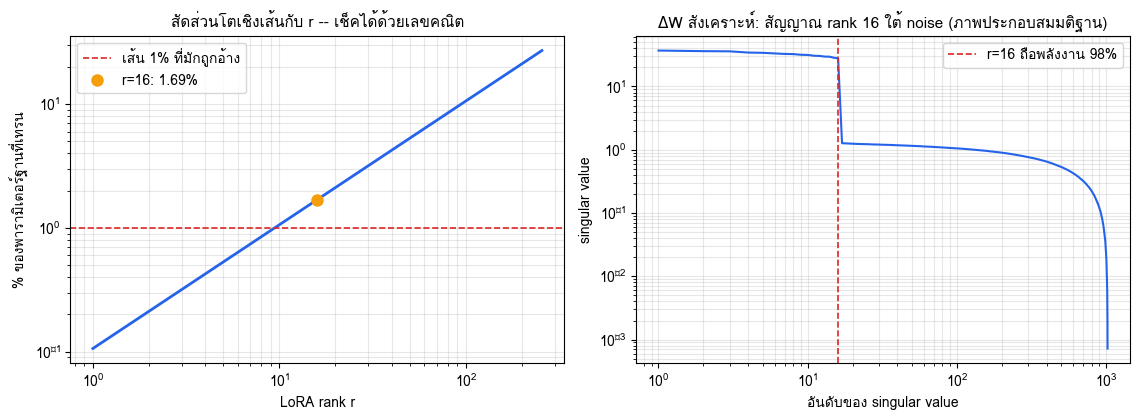

บันทึกรูปแล้ว: fig_lora_math.png
16 ทิศทางแรกของ ΔW สังเคราะห์ถือพลังงาน 97.6% -- ถ้า update จริงหน้าตาแบบนี้ adapter rank 16 ก็เก็บเนื้อหาไว้ได้เกือบหมด


In [ ]:
# -----------------------------------------------------------------------------
# หัวข้อ 4 -- เลขคณิต LoRA จากมิติจริงของ config + สมมติฐาน low-rank
# เซลล์นี้ไม่ใช้เน็ต (ใช้แค่ config ของโมเดลที่โหลดใน Cell 1)
# -----------------------------------------------------------------------------
import matplotlib.pyplot as plt

from kobeval import use_thai_font

use_thai_font()

H = cfg.hidden_size                      # 1024
INTER = cfg.intermediate_size            # 3072
N_LAYERS = cfg.num_hidden_layers         # 28
HEAD_DIM = getattr(cfg, "head_dim", H // cfg.num_attention_heads)
Q_OUT = cfg.num_attention_heads * HEAD_DIM      # 16 * 128 = 2048
KV_OUT = cfg.num_key_value_heads * HEAD_DIM     # 8  * 128 = 1024 (GQA)

# มิติ (d, k) ของทั้ง 7 เมทริกซ์ที่เราจะติด adapter
TARGET_SHAPES = {
    "q_proj": (H, Q_OUT), "k_proj": (H, KV_OUT), "v_proj": (H, KV_OUT),
    "o_proj": (Q_OUT, H),
    "gate_proj": (H, INTER), "up_proj": (H, INTER), "down_proj": (INTER, H),
}


def adapter_params(r):
    """จำนวนพารามิเตอร์ adapter ทั้งโมเดล = sum ต่อเลเยอร์ของ r(d+k) คูณจำนวนเลเยอร์"""
    return N_LAYERS * sum(r * (d + k) for d, k in TARGET_SHAPES.values())


N_BASE = sum(p.numel() for p in model.parameters())
EXPECTED_ADAPTER_PARAMS = 10_092_544
LORA_R = 16

print(f"พารามิเตอร์ฐาน (นับจริงจากโมเดล) : {N_BASE:,}")
assert N_BASE == 596_049_920, f"ฐานไม่ตรงที่คาด: {N_BASE:,}"

per_layer = sum(LORA_R * (d + k) for d, k in TARGET_SHAPES.values())
print(f"adapter ต่อเลเยอร์ที่ r={LORA_R}     : {per_layer:,}")
print(f"adapter ทั้งโมเดล ({N_LAYERS} เลเยอร์)   : {adapter_params(LORA_R):,}")
assert adapter_params(LORA_R) == EXPECTED_ADAPTER_PARAMS, "เลขคณิตไม่ตรงกับค่าที่ตรึงไว้"

pct_base = 100 * EXPECTED_ADAPTER_PARAMS / N_BASE
pct_peft = 100 * EXPECTED_ADAPTER_PARAMS / (N_BASE + EXPECTED_ADAPTER_PARAMS)
print(f"สัดส่วน (ตัวหาร = ฐานล้วน)        : {pct_base:.2f}%   <- เลข 1.69% ในบทความ")
print(f"สัดส่วน (ตัวหาร = ฐาน+adapter)    : {pct_peft:.2f}%   <- นิยามที่ peft ใช้พิมพ์")
r_under_1pct = max(r for r in range(1, 257) if 100 * adapter_params(r) / N_BASE < 1.0)
print(f'"ต่ำกว่า 1%" เป็นจริงก็ต่อเมื่อ r <= {r_under_1pct} เท่านั้น (เราใช้ r={LORA_R})')

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))

rs = np.arange(1, 257)
pcts = np.array([100 * adapter_params(int(r)) / N_BASE for r in rs])
axes[0].plot(rs, pcts, color="#2563eb", lw=2)
axes[0].axhline(1.0, ls="--", color="#dc2626", lw=1.2, label="เส้น 1% ที่มักถูกอ้าง")
axes[0].plot([LORA_R], [pct_base], "o", ms=8, color="#f59e0b",
             label=f"r={LORA_R}: {pct_base:.2f}%")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("LoRA rank r"); axes[0].set_ylabel("% ของพารามิเตอร์ฐานที่เทรน")
axes[0].set_title("สัดส่วนโตเชิงเส้นกับ r -- เช็คได้ด้วยเลขคณิต", fontsize=11)
axes[0].legend(); axes[0].grid(alpha=0.3, which="both"); axes[0].set_axisbelow(True)

# สมมติฐาน low-rank: Delta W สังเคราะห์ = สัญญาณ rank 16 + noise เต็ม rank
rng = np.random.default_rng(SEED)
signal = sum(np.outer(rng.standard_normal(1024), rng.standard_normal(1024))
             for _ in range(16)) / np.sqrt(1024)
noise = rng.standard_normal((1024, 1024)) * 0.02
sv = np.linalg.svd(signal + noise, compute_uv=False)
energy16 = 100 * (sv[:16] ** 2).sum() / (sv ** 2).sum()
axes[1].plot(np.arange(1, 1025), sv, color="#2563eb", lw=1.5)
axes[1].axvline(16, ls="--", color="#dc2626", lw=1.2, label=f"r=16 ถือพลังงาน {energy16:.0f}%")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("อันดับของ singular value"); axes[1].set_ylabel("singular value")
axes[1].set_title("ΔW สังเคราะห์: สัญญาณ rank 16 ใต้ noise (ภาพประกอบสมมติฐาน)", fontsize=11)
axes[1].legend(); axes[1].grid(alpha=0.3, which="both"); axes[1].set_axisbelow(True)

fig.tight_layout()
fig.savefig("fig_lora_math.png", dpi=150, bbox_inches="tight")
plt.show()
print("บันทึกรูปแล้ว: fig_lora_math.png")
print(f"16 ทิศทางแรกของ ΔW สังเคราะห์ถือพลังงาน {energy16:.1f}% -- "
      "ถ้า update จริงหน้าตาแบบนี้ adapter rank 16 ก็เก็บเนื้อหาไว้ได้เกือบหมด")


---

## 6. เตรียมข้อมูล (Data)

เราใช้ `airesearch/wangchanx-seed-free-synthetic-instruct-thai-120k` —
ชุดคำสั่ง-คำตอบภาษาไทยแบบ synthetic 120,000 คู่ จากทีม WangchanX (สุ่มมาใช้ 4,000)

สามเรื่องที่เซลล์ถัดไปทำอย่างระมัดระวัง:

1. **หาชื่อคอลัมน์แบบไม่ตายตัว** — schema ของชุดข้อมูลสาธารณะเปลี่ยนได้
   เราจึงไล่หาคอลัมน์คำถาม/คำตอบจากรายชื่อ candidate แทนการ hardcode
2. **เรียก `apply_chat_template` ครั้งเดียว ที่นี่ที่เดียว** พร้อม `enable_thinking=False`
   — การ template ซ้ำสองรอบคือกับดักข้อ 2 ของบทความ (อาการ: `<|im_start|>` ซ้อนสองชั้น)
   แล้วทำพิธีที่ควรเป็นนิสัย: **decode ตัวอย่างแรกออกมาดูด้วยตาเสมอ**
3. **นับ token แล้วคัดตัวอย่างที่เกินงบ 768 ทิ้งก่อนเทรน** — ตัวอย่างที่โดนตัดท้าย
   จะเสีย `<|im_end|>` ของคำตอบไป กลายเป็นการสอนโมเดลว่า "ไม่ต้องหยุดก็ได้"
   (กับดักข้อ 3 ของบทความ)

เซลล์นี้ยังวัด **สัดส่วน token ฝั่ง prompt เทียบฝั่งคำตอบ** ของชุดข้อมูลจริง
ตัวเลขนี้คือหัวใจของรูป 2.1 ในบทความ: ถ้าไม่ mask, gradient ราวนี้แหละ
จะถูกใช้หัดเขียนคำถามของผู้ใช้แทนที่จะหัดตอบ


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/119M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/118898 [00:00<?, ? examples/s]

wangchanx columns: ['instruction', 'context', 'output', 'type', 'context_length', 'rating', 'qc_rationale']  n=118898
ใช้คอลัมน์: คำถาม='instruction'  คำตอบ='output'


ผ่านการคัดกรองความยาวอักขระ: 6639


tokenize 6631 ตัวอย่างใช้เวลา 7 วินาที
ตัวอย่างที่ยาวเกินงบ 768 token: 7 (0.1%) -> คัดทิ้งก่อนเทรน (กับดักข้อ 3)

พิธีที่ควรเป็นนิสัย: decode ตัวอย่างแรกออกมาดูด้วยตา ---------------------
<|im_start|>user
กรุณาสรุปเนื้อหาในรูปแบบของย่อหน้าจากข้อความที่กำหนด<|im_end|>
<|im_start|>assistant
<think>

</think>

การละเล่นท้องถิ่นนี้เรียกว่า 'ปิงปองคน' ซึ่งผู้เล่นจะโยนลูกปิงปองขึ้นสูงเหนือหัวราวหนึ่งช่วงตัวแล้วเอ่ยชื่อผู้เล่นคนอื่น ผู้ที่ถูกเรียกชื่อต้องวิ่งมารับลูกปิงปองที่กระเด้งขึ้นมาจากพื้นในครั้งเดียว ถ้ารับไม่ทัน ผู้ที่โยนจะได้ลูกปิงปองแล้วขว้างให้โดนผู้เล่นคนอื่น ผู้ที่โดนจะเสียน่
------------------------------------------------------------------------------
ตรวจ 50 ตัวอย่างแรก: template ปรากฏอย่างละครั้งเดียวต่อ turn -> ผ่าน

ความยาวเฉลี่ยทั้งตัวอย่าง : 319 token
ความยาวเฉลี่ยฝั่ง prompt : 64 token
สัดส่วน token ฝั่ง prompt : 20.1%
=> ถ้าเทรนโดยไม่ mask, 20% ของพจน์ใน loss คือการหัดเขียนคำถามของผู้ใช้


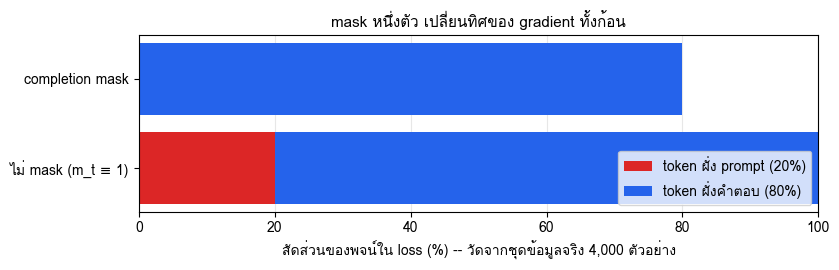

บันทึกรูปแล้ว: fig_mask_accounting.png


In [ ]:
# -----------------------------------------------------------------------------
# หัวข้อ 6 -- โหลดข้อมูลคำสั่งภาษาไทย, ใส่ chat template ครั้งเดียว, คัดที่เกินงบทิ้ง
# -----------------------------------------------------------------------------
from datasets import Dataset, load_dataset

N_TRAIN = 2000 if FAST_MODE else 4000   # ตามบทความ (FAST_MODE ลดครึ่งหนึ่ง)
N_PROBE = 8                             # คำถาม held-out ไว้เทียบ generation ในหัวข้อ 8-9
MAX_SEQ_LEN = 768
RESPONSE_TEMPLATE = "<|im_start|>assistant\n"   # ทุกอย่างก่อนหน้านี้ = prompt


def pick_column(columns, candidates):
    """หาชื่อคอลัมน์แบบไม่แคร์ตัวพิมพ์ใหญ่เล็ก -- schema ของชุดข้อมูลสาธารณะเปลี่ยนได้"""
    lower = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand in lower:
            return lower[cand]
    return None


raw = load_dataset("airesearch/wangchanx-seed-free-synthetic-instruct-thai-120k", split="train")
print(f"wangchanx columns: {raw.column_names}  n={len(raw)}")

q_col = pick_column(raw.column_names, ["instruction", "question", "input", "prompt"])
a_col = pick_column(raw.column_names, ["output", "response", "answer", "completion"])
assert None not in (q_col, a_col), f"schema ไม่ตรงที่คาด: {raw.column_names}"
print(f"ใช้คอลัมน์: คำถาม={q_col!r}  คำตอบ={a_col!r}")

# ดึง pool ใหญ่กว่าที่ต้องใช้ เผื่อโดนคัดออกตอนกรองความยาว
raw = raw.shuffle(seed=SEED).select(range(min(N_TRAIN + 3000, len(raw))))

cand = []
for row in raw:
    q, a = row[q_col], row[a_col]
    if not (isinstance(q, str) and isinstance(a, str)):
        continue
    q, a = q.strip(), a.strip()
    if 10 <= len(q) <= 500 and 30 <= len(a) <= 1200:
        cand.append((q, a))
print(f"ผ่านการคัดกรองความยาวอักขระ: {len(cand)}")

probe_questions = [q for q, _ in cand[:N_PROBE]]   # แยก held-out ออกก่อน ห้ามเทรน
cand = cand[N_PROBE:]


def to_text(q, a):
    """ใส่ chat template ครั้งเดียวที่นี่ที่เดียว (ปิด thinking mode ของ Qwen3)"""
    return tokenizer.apply_chat_template(
        [{"role": "user", "content": q}, {"role": "assistant", "content": a}],
        tokenize=False,
        enable_thinking=False,
    )


t0 = time.time()
all_texts = [to_text(q, a) for q, a in cand]
total_lens = [len(ids) for ids in tokenizer(all_texts, add_special_tokens=False).input_ids]
prompt_parts = [t[: t.index(RESPONSE_TEMPLATE) + len(RESPONSE_TEMPLATE)] for t in all_texts]
prompt_lens = [len(ids) for ids in tokenizer(prompt_parts, add_special_tokens=False).input_ids]
print(f"tokenize {len(all_texts)} ตัวอย่างใช้เวลา {time.time() - t0:.0f} วินาที")

n_over = sum(1 for n in total_lens if n > MAX_SEQ_LEN)
print(f"ตัวอย่างที่ยาวเกินงบ {MAX_SEQ_LEN} token: {n_over} "
      f"({100 * n_over / len(all_texts):.1f}%) -> คัดทิ้งก่อนเทรน (กับดักข้อ 3)")

kept = [(cand[i][0], cand[i][1], all_texts[i], prompt_lens[i], total_lens[i])
        for i in range(len(all_texts)) if total_lens[i] <= MAX_SEQ_LEN][:N_TRAIN]
assert len(kept) == N_TRAIN, f"เหลือ {len(kept)} ตัวอย่าง ไม่ครบ {N_TRAIN} -- เพิ่มขนาด pool"

train_ds = Dataset.from_dict({"text": [t for _, _, t, _, _ in kept]})
# รูปแบบ conversational เผื่อ trl รุ่นใหม่ที่ตัด collator ออก (ดูหัวข้อ 7.2)
train_msgs_records = [
    {"messages": [{"role": "user", "content": q}, {"role": "assistant", "content": a}]}
    for q, a, _, _, _ in kept
]

sum_prompt = sum(pl for _, _, _, pl, _ in kept)
sum_total = sum(tl for _, _, _, _, tl in kept)
PROMPT_TOKEN_FRAC = sum_prompt / sum_total
DATA_STATS = {
    "n_train": len(kept),
    "n_probe_heldout": len(probe_questions),
    "n_dropped_overlength": n_over,
    "max_seq_len": MAX_SEQ_LEN,
    "mean_total_tokens": sum_total / len(kept),
    "mean_prompt_tokens": sum_prompt / len(kept),
    "prompt_token_frac": PROMPT_TOKEN_FRAC,
}

print()
print("พิธีที่ควรเป็นนิสัย: decode ตัวอย่างแรกออกมาดูด้วยตา ---------------------")
print(train_ds[0]["text"][:400])
print("-" * 78)
for probe_text in [r[2] for r in kept[:50]]:
    assert probe_text.count("<|im_start|>user") == 1, "template ซ้อนสองชั้น (กับดักข้อ 2)"
    assert probe_text.count(RESPONSE_TEMPLATE) == 1, "template ซ้อนสองชั้น (กับดักข้อ 2)"
print("ตรวจ 50 ตัวอย่างแรก: template ปรากฏอย่างละครั้งเดียวต่อ turn -> ผ่าน")

print()
print(f"ความยาวเฉลี่ยทั้งตัวอย่าง : {DATA_STATS['mean_total_tokens']:.0f} token")
print(f"ความยาวเฉลี่ยฝั่ง prompt : {DATA_STATS['mean_prompt_tokens']:.0f} token")
print(f"สัดส่วน token ฝั่ง prompt : {100 * PROMPT_TOKEN_FRAC:.1f}%")
print(f"=> ถ้าเทรนโดยไม่ mask, {100 * PROMPT_TOKEN_FRAC:.0f}% ของพจน์ใน loss "
      "คือการหัดเขียนคำถามของผู้ใช้")

fig, ax = plt.subplots(figsize=(8.5, 2.8))
ax.barh(["ไม่ mask (m_t ≡ 1)"], [100 * PROMPT_TOKEN_FRAC], color="#dc2626",
        label=f"token ฝั่ง prompt ({100 * PROMPT_TOKEN_FRAC:.0f}%)")
ax.barh(["ไม่ mask (m_t ≡ 1)"], [100 * (1 - PROMPT_TOKEN_FRAC)],
        left=[100 * PROMPT_TOKEN_FRAC], color="#2563eb",
        label=f"token ฝั่งคำตอบ ({100 * (1 - PROMPT_TOKEN_FRAC):.0f}%)")
ax.barh(["completion mask"], [100 * (1 - PROMPT_TOKEN_FRAC)], color="#2563eb")
ax.set_xlim(0, 100)
ax.set_xlabel("สัดส่วนของพจน์ใน loss (%) -- วัดจากชุดข้อมูลจริง 4,000 ตัวอย่าง")
ax.set_title("mask หนึ่งตัว เปลี่ยนทิศของ gradient ทั้งก้อน", fontsize=11)
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig("fig_mask_accounting.png", dpi=150, bbox_inches="tight")
plt.show()
print("บันทึกรูปแล้ว: fig_mask_accounting.png")


---

## 7. โค้ดหลัก (Main code)

### 7.1 ติด LoRA adapter แล้ว assert จำนวนพารามิเตอร์

`get_peft_model` ติดเมทริกซ์ $A, B$ ทับทั้ง 7 เมทริกซ์เป้าหมายในทุกเลเยอร์
แล้วแช่แข็งน้ำหนักฐานทั้งหมด เซลล์ถัดไปให้ `peft` พิมพ์ตัวเลขจริงด้วย
`print_trainable_parameters()` แล้ว **assert กับ 10,092,544 ที่คำนวณด้วยมือในหัวข้อ 4**

> **เปอร์เซ็นต์ที่ peft พิมพ์จะไม่ใช่ 1.69 เป๊ะ — ไม่ใช่ bug**
> `peft` คิดเปอร์เซ็นต์โดยหารด้วยจำนวนพารามิเตอร์ *รวม adapter แล้ว* (~1.67%)
> ส่วน 1.69% ของบทความหารด้วยพารามิเตอร์ฐานล้วน ๆ นิยามต่างกันนิดเดียว
> ตัวเลขจึงต่างกันนิดเดียว — ประเด็นของหัวข้อ 3.3: ต้องรู้ที่มาของเศษกับส่วน
> ไม่ใช่จำตัวเลขลอย ๆ ไปอ้างต่อ

### กับดัก fp16 ที่ต้องปิดก่อนเริ่ม

ตอนที่ 1 เราต้อง `model.float()` ทั้งโมเดลก่อนเทรน เพราะเทรนทุกพารามิเตอร์
ตอนนี้ base ถูกแช่แข็ง — ไม่มี gradient — จึงอยู่เป็น fp16 ได้สบาย ๆ และประหยัด VRAM ไปครึ่งหนึ่ง
สิ่งที่ต้องเป็น fp32 คือ **เฉพาะพารามิเตอร์ที่เทรนได้** (adapter ราว 10 ล้านตัว)
ถ้าลืม จะเจอ `ValueError: Attempting to unscale FP16 gradients.` ตั้งแต่ step แรก
— error ตัวเดียวกับตอนที่ 1 เป๊ะ แต่คราวนี้ค่าแก้ถูกกว่ากันมาก:
cast 10 ล้านพารามิเตอร์ ไม่ใช่ 596 ล้าน


In [ ]:
# -----------------------------------------------------------------------------
# หัวข้อ 7.1 -- ติด LoRA + assert จำนวนพารามิเตอร์ + cast เฉพาะ adapter เป็น fp32
# -----------------------------------------------------------------------------
from peft import LoraConfig, get_peft_model

lora_cfg = LoraConfig(
    r=16,
    lora_alpha=32,         # alpha/r = 2 -- ดูสมการ 3.2
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
)

policy = get_peft_model(model, lora_cfg)
policy.print_trainable_parameters()    # เชื่อบรรทัดนี้ ไม่ใช่ตัวเลขในบล็อกไหนทั้งนั้น

n_train = sum(p.numel() for p in policy.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in policy.parameters())
assert n_train == EXPECTED_ADAPTER_PARAMS, (
    f"peft นับได้ {n_train:,} แต่เลขคณิตหัวข้อ 4 บอก {EXPECTED_ADAPTER_PARAMS:,} -- "
    "ถ้าไม่ตรง แปลว่า target_modules หรือ r ไม่ตรงกับที่คำนวณ"
)
print(f"\nassert ผ่าน: adapter มี {n_train:,} พารามิเตอร์ ตรงกับ r(d+k) ที่คำนวณด้วยมือ")
print(f"  % เทียบฐานล้วน (นิยามบทความ)  : {100 * n_train / N_BASE:.2f}%")
print(f"  % เทียบฐาน+adapter (นิยาม peft): {100 * n_train / n_total:.2f}%")


def cast_trainable_to_fp32(m):
    """กับดัก fp16: cast 'เฉพาะพารามิเตอร์ที่เทรนได้' เป็น fp32 -- ฐาน 596M ตัวยังเป็น fp16"""
    n_cast = 0
    for _, p in m.named_parameters():
        if p.requires_grad and p.dtype != torch.float32:
            p.data = p.data.float()
            n_cast += 1
    return n_cast


n_cast = cast_trainable_to_fp32(policy)
VRAM_AFTER_LORA = torch.cuda.memory_allocated() / (1024 ** 3)
print(f"\ncast adapter เป็น fp32 ไป {n_cast} tensors")
print(f"VRAM ก่อนติด adapter : {VRAM_AFTER_BASE:.3f} GB")
print(f"VRAM หลังติด adapter : {VRAM_AFTER_LORA:.3f} GB "
      f"(+{VRAM_AFTER_LORA - VRAM_AFTER_BASE:.3f} GB)")

# B ถูก init เป็นศูนย์ -> adapter ยังไม่เปลี่ยนอะไรเลย (สมการ 3.2)
# วิธีตรวจที่ถูก: เทียบ logits ตอน "เปิด" กับ "ปิด" adapter บนโมเดลตัวเดียวกัน
# (เทียบกับตัวแปร `model` ตรง ๆ ไม่ได้ เพราะ get_peft_model ฉีด LoRA เข้าไปใน
#  module เดิมแบบ in-place -- `model` กับ `policy` จึงคือ network เดียวกันไปแล้ว)
policy.eval()
with torch.no_grad():
    probe = tokenizer("สวัสดีครับ วันนี้อากาศ", return_tensors="pt").to(DEV)
    logits_on = policy(**probe).logits
    with policy.disable_adapter():
        logits_off = policy(**probe).logits
same = bool(torch.allclose(logits_on, logits_off))
print(f"\nB=0 ทำให้เปิด/ปิด adapter ได้ logits เท่ากัน: {same}")
print("การเทรนจึงออกตัวจาก base เป๊ะ ๆ -- และ 'ปิด adapter' คือปุ่มย้อนกลับ")
print("ที่เราจะใช้วัด 'ก่อน SFT' ในหัวข้อ 8 และที่ตอนที่ 3-4 ใช้สร้าง reference model ฟรี ๆ")


trainable params: 10,092,544 || all params: 606,142,464 || trainable%: 1.6650

assert ผ่าน: adapter มี 10,092,544 พารามิเตอร์ ตรงกับ r(d+k) ที่คำนวณด้วยมือ
  % เทียบฐานล้วน (นิยามบทความ)  : 1.69%
  % เทียบฐาน+adapter (นิยาม peft): 1.67%

cast adapter เป็น fp32 ไป 0 tensors
VRAM ก่อนติด adapter : 1.110 GB
VRAM หลังติด adapter : 1.156 GB (+0.046 GB)



B=0 ทำให้เปิด/ปิด adapter ได้ logits เท่ากัน: True
การเทรนจึงออกตัวจาก base เป๊ะ ๆ -- และ 'ปิด adapter' คือปุ่มย้อนกลับ
ที่เราจะใช้วัด 'ก่อน SFT' ในหัวข้อ 8 และที่ตอนที่ 3-4 ใช้สร้าง reference model ฟรี ๆ


### 7.2 Completion mask — collator ที่ทำหน้าที่เป็น $m_t$

`DataCollatorForCompletionOnlyLM` ตั้ง label ของ token ทุกตัวก่อน `<|im_start|>assistant`
เป็น `-100` ซึ่งเป็นค่าที่ loss ของ PyTorch ข้ามให้ — mask ตัวเดียวกับที่ตอนที่ 4
ใช้ในฟังก์ชัน `seq_logp` โผล่มาคนละตอน

สองเรื่องที่เซลล์ถัดไปทำแบบตั้งใจ:

1. **จัดการความต่างของเวอร์ชัน trl อย่างระวัง** — trl 0.16.x (ที่ Cell 0 pin ไว้) ใช้
   `DataCollatorForCompletionOnlyLM` แต่ trl รุ่นใหม่ตัด collator ตัวนี้ออกแล้วให้ใช้
   `assistant_only_loss=True` ใน `SFTConfig` แทน โค้ดจะเลือกเส้นทางที่มีจริงในเวอร์ชัน
   ที่ติดตั้งอยู่ และ **พิมพ์บอกว่าใช้เส้นทางไหน**
2. **พิสูจน์ว่า mask ทำงานจริงก่อนเทรน** — เอาตัวอย่างจริงหนึ่งตัวผ่าน collator
   แล้ว assert ว่า label ฝั่ง prompt เป็น `-100` ทั้งหมด และ token แรกที่ไม่ถูก mask
   อยู่หลัง `<|im_start|>assistant` พอดี

> **กับดักข้อ 1 ของบทความ: `tokenizer.pad_token = tokenizer.eos_token`**
> บรรทัดที่ถูก copy ต่อกันมากที่สุดในวงการ — กับ tokenizer ที่ไม่มี pad token มันจำเป็น
> แต่ถ้า pad กับ eos เป็น token เดียวกัน collator จะ mask eos จริง ๆ ท้ายคำตอบทิ้งไปด้วย
> โมเดลจึงไม่เคยถูกสอนให้ "พูดจบ" — Qwen3 มี pad (`<|endoftext|>`) แยกจาก eos (`<|im_end|>`)
> อยู่แล้ว เซลล์ถัดไปพิมพ์ id ทั้งสองให้เห็นกับตา **อย่า** เอาบรรทัดนั้นจาก tutorial อื่นมาเขียนทับ


In [ ]:
# -----------------------------------------------------------------------------
# หัวข้อ 7.2 -- เลือกเส้นทาง completion mask ตามเวอร์ชัน trl + พิสูจน์ว่า mask ทำงานจริง
# -----------------------------------------------------------------------------
import inspect

import trl
from trl import SFTConfig, SFTTrainer

try:
    from trl import DataCollatorForCompletionOnlyLM
    HAVE_COLLATOR = True
except ImportError:
    DataCollatorForCompletionOnlyLM = None
    HAVE_COLLATOR = False

HAVE_ASSISTANT_ONLY = "assistant_only_loss" in inspect.signature(SFTConfig.__init__).parameters

if HAVE_COLLATOR:
    MASK_PATH = "collator"       # trl 0.16.x ตามที่ Cell 0 pin ไว้
elif HAVE_ASSISTANT_ONLY:
    MASK_PATH = "assistant_only_loss"   # trl รุ่นใหม่ที่ตัด collator ออกแล้ว
else:
    raise RuntimeError(f"trl {trl.__version__} ไม่มีทั้งสองเส้นทาง -- ตรวจเวอร์ชันใน Cell 0")

print(f"trl {trl.__version__} -> เส้นทาง completion mask ที่ใช้: {MASK_PATH}")

print(f"\npad token: {tokenizer.pad_token!r} (id={tokenizer.pad_token_id})")
print(f"eos token: {tokenizer.eos_token!r} (id={tokenizer.eos_token_id})")
assert tokenizer.pad_token_id != tokenizer.eos_token_id, (
    "pad == eos: collator จะ mask eos ท้ายคำตอบทิ้ง แล้วโมเดลจะเลิกหยุดพูด (กับดักข้อ 1)"
)
print("pad != eos -> eos ท้ายคำตอบจะไม่โดน mask ทิ้ง (กับดักข้อ 1 ผ่าน)")

if MASK_PATH == "collator":
    collator = DataCollatorForCompletionOnlyLM(
        response_template=RESPONSE_TEMPLATE,   # ทุกอย่างก่อนหน้านี้ = prompt
        tokenizer=tokenizer,
    )

    # --- พิสูจน์ว่า mask ทำงานจริง ก่อนจ่ายค่าเทรน 9 นาที ---------------------
    sample_ids = tokenizer(train_ds[0]["text"], truncation=True,
                           max_length=MAX_SEQ_LEN).input_ids
    batch = collator([{"input_ids": sample_ids}])
    labels = batch["labels"][0]

    n_masked = int((labels == -100).sum())
    unmasked_pos = (labels != -100).nonzero(as_tuple=True)[0]
    assert len(unmasked_pos) > 0, "ไม่มี token ไหนถูกนับใน loss เลย -- template ไม่ตรง"
    first_unmasked = int(unmasked_pos[0])

    # ตำแหน่งแรกที่ไม่ถูก mask ต้องอยู่ 'หลัง' template ของฝั่งคำตอบพอดี
    prefix_ids = sample_ids[:first_unmasked]
    prefix_text = tokenizer.decode(prefix_ids)
    assert prefix_text.endswith(RESPONSE_TEMPLATE), (
        "ขอบเขต mask ไม่ตรงกับ response template -- ตรวจ RESPONSE_TEMPLATE"
    )
    assert (labels[:first_unmasked] == -100).all(), "มี token ฝั่ง prompt หลุดเข้ามาใน loss"

    print()
    print(f"ตัวอย่างที่ใช้พิสูจน์ยาว {len(sample_ids)} token")
    print(f"  ถูก mask (-100)      : {n_masked} token (ฝั่ง prompt + padding)")
    print(f"  ถูกนับใน loss        : {len(unmasked_pos)} token (ฝั่งคำตอบ)")
    print(f"  token แรกที่นับใน loss: ตำแหน่ง {first_unmasked} "
          f"-- อยู่ถัดจาก {RESPONSE_TEMPLATE!r} พอดี")
    first_tokens = tokenizer.decode([int(t) for t in labels[unmasked_pos[:12]]])
    print(f"  12 token แรกที่นับ    : {first_tokens!r}")
    print("=> mask ทำงานตรงตามสมการ 3.1 จริง ไม่ใช่แค่เชื่อเอกสาร")
else:
    collator = None
    print()
    print("เส้นทาง assistant_only_loss: SFTTrainer จะ mask ให้เองจาก chat template")
    print("(ต้องส่ง dataset แบบ conversational -- เตรียมไว้แล้วใน train_msgs_records)")


trl 0.16.1 -> เส้นทาง completion mask ที่ใช้: collator

pad token: '<|endoftext|>' (id=151643)
eos token: '<|im_end|>' (id=151645)
pad != eos -> eos ท้ายคำตอบจะไม่โดน mask ทิ้ง (กับดักข้อ 1 ผ่าน)

ตัวอย่างที่ใช้พิสูจน์ยาว 439 token
  ถูก mask (-100)      : 36 token (ฝั่ง prompt + padding)
  ถูกนับใน loss        : 403 token (ฝั่งคำตอบ)
  token แรกที่นับใน loss: ตำแหน่ง 36 -- อยู่ถัดจาก '<|im_start|>assistant\n' พอดี
  12 token แรกที่นับ    : '<think>\n\n</think>\n\nการละเล่นท้องถิ'
=> mask ทำงานตรงตามสมการ 3.1 จริง ไม่ใช่แค่เชื่อเอกสาร


---

## รันจริง — เทรน SFT แบบ completion mask

ค่าที่ใช้ตรงกับบทความ: lr `2e-4`, cosine schedule, warmup 3%, batch 4 × grad accum 4
(effective 16), 1 epoch บน 4,000 ตัวอย่าง = 250 optimizer step, `packing=False`
(completion mask ใช้กับ packing ตรง ๆ ไม่ได้)

> **ทำไม 2e-4 ถึงปลอดภัยที่นี่ แต่เป็นหายนะในตอนที่ 1**
> learning rate ตัวเดียวกันนี้ ถ้าใช้เทรน *ทุก* พารามิเตอร์ จะลบความสามารถของโมเดล
> ภายในไม่กี่ร้อย step แต่กับ LoRA มันปลอดภัย เพราะ (1) น้ำหนักเดิม 596 ล้านตัวถูกแช่แข็ง
> — ความรู้ใน base ไม่มีทางถูกเขียนทับ (2) $B$ เริ่มจากศูนย์ — โมเดล ณ step แรกคือ base เป๊ะ ๆ
> สิ่งที่แย่ที่สุดที่ LoRA ทำได้คือ adapter ที่แย่ ซึ่งถอดทิ้งได้ทุกเมื่อ

เทรนเสร็จเราเซฟ **เฉพาะส่วนแก้** (~40 MB ไม่ใช่ 1.2 GB) แล้วพิมพ์วิธี push ขึ้น hub
เป็น `kobkrit/qwen3-0.6b-th-sft-lora` — adapter ตัวนี้คือจุดตั้งต้นของตอนที่ 3 ถึง 7


:::danger กับดัก OOM ของ TRL ที่ไม่เกี่ยวกับขนาดโมเดลเลย

รันจริงบน T4 แล้ว OOM ตอน step 27 ทั้งที่ LoRA ใช้ VRAM น้อยมาก สาเหตุอยู่ใน TRL:

```
sft_trainer.py:577  shift_logits = outputs.logits[..., :-1, :].contiguous()
OutOfMemoryError: Tried to allocate 1.71 GiB
```

`SFTTrainer` คำนวณ **token accuracy** ไว้โชว์ตอน log โดยเรียก `.contiguous()`
ซึ่ง "ก๊อป logits ทั้งก้อน" ขึ้นมาอีกชุด และ logits ของ Qwen3 ใหญ่มากเพราะ vocab
มีถึง 151,936 ช่อง:

`batch 4 x seq 768 x vocab 151,936 x 4 ไบต์ = 1.74 GB` -- แล้วสำเนาอีกชุดเป็น **3.48 GB**

เราจึงลด `per_device_train_batch_size` จาก 4 เหลือ 2 และเพิ่ม
`gradient_accumulation_steps` จาก 4 เป็น 8 -- **effective batch ยังเท่ากับ 16 เท่าเดิม**
คือผลการเทรนเหมือนเดิมทุกประการ แต่ logits ที่ต้องถือไว้พร้อมกันลดลงครึ่งหนึ่ง

บทเรียนที่ใช้ได้ทั่วไป: เวลา OOM ให้ดูก่อนว่า **tensor ก้อนไหนใหญ่ที่สุด** มักไม่ใช่
ตัวโมเดล แต่เป็น logits (batch x seq x vocab) ซึ่งโตตาม vocab ที่เราควบคุมไม่ได้
:::

In [ ]:
# -----------------------------------------------------------------------------
# หัวข้อ 7.3 -- เทรนจริง (แบบ completion mask) แล้วเซฟ adapter
# -----------------------------------------------------------------------------
# -----------------------------------------------------------------------------
# ปิดการนับ token accuracy ของ TRL -- ต้นตอ OOM ตัวจริง
# -----------------------------------------------------------------------------
# SFTTrainer.compute_loss ของ TRL เรียก outputs.logits[..., :-1, :].contiguous()
# เพื่อคำนวณ accuracy ไว้โชว์ใน log ซึ่ง "ก๊อป logits ทั้งก้อน" ขึ้นมาอีกชุด
# logits ของ Qwen3 = batch x seq x 151,936 คำ ทำให้สำเนานั้นใหญ่กว่าตัวโมเดลเสียอีก
# เราไม่ได้ใช้ตัวเลข accuracy นั้นเลย จึงข้ามมันทิ้งไปตรง ๆ
from transformers import Trainer as _HFTrainer

_HF_LOSS_PARAMS = inspect.signature(_HFTrainer.compute_loss).parameters


class LeanSFTTrainer(SFTTrainer):
    """SFTTrainer ที่ไม่คำนวณ token accuracy (ประหยัด logits ไปหนึ่งชุดเต็ม)"""

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        if "num_items_in_batch" not in _HF_LOSS_PARAMS:
            kwargs.pop("num_items_in_batch", None)   # รองรับ transformers รุ่นเก่า
        return _HFTrainer.compute_loss(
            self, model, inputs, return_outputs=return_outputs, **kwargs
        )


sft_kwargs = dict(
    output_dir="sft-out",
    per_device_train_batch_size=2,   # ดูหมายเหตุ OOM ด้านล่าง
    gradient_accumulation_steps=8,    # effective batch ยังเท่ากับ 16 เท่าเดิม
    num_train_epochs=1,
    learning_rate=2e-4,               # LoRA รับไหว -- full FT ที่ค่านี้คือหายนะ (ตอนที่ 1)
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,
    fp16=USE_FP16,                    # บน T4 ค่านี้คือ True (มาจาก Cell 0)
    bf16=SUPPORTS_BF16,               # บน T4 ค่านี้คือ False
    logging_steps=10,
    save_strategy="no",
    report_to="none",
    seed=SEED,
    # เก็บ activation ไว้เฉพาะบางจุดแล้วคำนวณซ้ำตอน backward
    # แลกเวลา ~20-30% กับ VRAM ที่ลดลงมาก -- จำเป็นบน T4
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},   # ต้องใช้ False กับ PEFT
)

# ชื่อ argument ต่างกันตามเวอร์ชัน trl -- เติมเฉพาะตัวที่มีจริง
_sig = inspect.signature(SFTConfig.__init__).parameters
if "max_seq_length" in _sig:
    sft_kwargs["max_seq_length"] = MAX_SEQ_LEN
elif "max_length" in _sig:
    sft_kwargs["max_length"] = MAX_SEQ_LEN
if "dataset_text_field" in _sig and MASK_PATH == "collator":
    sft_kwargs["dataset_text_field"] = "text"
if "packing" in _sig:
    sft_kwargs["packing"] = False     # completion mask ใช้กับ packing ตรง ๆ ไม่ได้
if MASK_PATH == "assistant_only_loss":
    sft_kwargs["assistant_only_loss"] = True

cfg_sft = SFTConfig(**sft_kwargs)
ds_for_trainer = train_ds if MASK_PATH == "collator" else Dataset.from_list(train_msgs_records)

policy.train()
trainer = LeanSFTTrainer(
    model=policy,
    args=cfg_sft,
    train_dataset=ds_for_trainer,
    data_collator=collator,           # None ในเส้นทาง assistant_only_loss
    processing_class=tokenizer,
)

torch.cuda.reset_peak_memory_stats()
t0 = time.time()
trainer.train()
TRAIN_TIME_MASKED = time.time() - t0
VRAM_PEAK_MASKED = torch.cuda.max_memory_allocated() / (1024 ** 3)
LOG_MASKED = [dict(h) for h in trainer.state.log_history]

print(f"\nเวลาเทรน  : {TRAIN_TIME_MASKED / 60:.1f} นาที")
print(f"VRAM peak : {VRAM_PEAK_MASKED:.2f} GB")

# เซฟ "เฉพาะส่วนแก้" -- ไม่ใช่โมเดลทั้งก้อน
ADAPTER_DIR = "qwen3-0.6b-th-sft-lora"
policy.save_pretrained(ADAPTER_DIR)
adapter_bytes = sum(
    os.path.getsize(os.path.join(ADAPTER_DIR, f)) for f in os.listdir(ADAPTER_DIR)
)
print(f"\nเซฟ adapter แล้วที่ {ADAPTER_DIR}/ ({adapter_bytes / 1e6:.1f} MB -- ไม่ใช่ 1.2 GB)")

print()
print("push ขึ้น Hugging Face Hub (ตอนที่ 3-7 จะโหลด adapter ตัวนี้ไปต่อยอด):")
print("  from huggingface_hub import login")
print("  login()  # ใช้ token ที่มีสิทธิ์ write")
print('  policy.push_to_hub("kobkrit/qwen3-0.6b-th-sft-lora")')
print('  tokenizer.push_to_hub("kobkrit/qwen3-0.6b-th-sft-lora")')


---

## 8. ผลลัพธ์ (Results)

วัดสามอย่างด้วยสัญญาการวัดผลเดิมทุกตัวอักษร แล้วเทียบกับ baseline จาก Cell 1:

1. **TH-INSTR accuracy พร้อม Wilson 95% CI** — rubric การทำตามคำสั่ง 30 ข้อ
2. **`th_ratio`** — สัดส่วนอักขระไทยในคำตอบ metric ประจำซีรีส์
3. **McNemar จาก `compare()`** — ความต่างที่เห็น แยกออกจากความบังเอิญได้หรือไม่

ข้อดีของ LoRA โผล่มาอีกครั้ง: การวัด "ก่อน" กับ "หลัง" ใช้โมเดลตัวเดียวกัน
เพราะ "ก่อน" คือแค่ปิด adapter — ไม่ต้องโหลดโมเดลใหม่ ไม่มีความเสี่ยงว่า
สองการวัดจะอยู่คนละสภาพแวดล้อม


In [ ]:
# -----------------------------------------------------------------------------
# หัวข้อ 8.1 -- วัด KobEval-TH ซ้ำด้วยสัญญาเดิม แล้วเทียบกับ baseline
# -----------------------------------------------------------------------------
policy.eval()
t0 = time.time()
after = evaluate(
    policy,
    tokenizer,
    slices=KOBEVAL_SLICES,
    seed=42,
    model_name="Qwen3-0.6B + SFT LoRA (mask)",
    out_path="results_after.json",
    extra={"train_time_s": TRAIN_TIME_MASKED, "vram_peak_gb": VRAM_PEAK_MASKED},
)
print(f"ใช้เวลาวัดผลหลัง SFT: {time.time() - t0:.0f} วินาที\n")

table = compare(baseline, after, out_path="results_table.json")

plot_before_after(
    baseline,
    after,
    slices=KOBEVAL_SLICES,
    title="ตอนที่ 2: ก่อน vs หลัง SFT + LoRA (completion mask)",
    out_path="fig_before_after.png",
    results_json="results_before_after.json",
)


In [ ]:
# -----------------------------------------------------------------------------
# หัวข้อ 8.2 -- generate จริงบนคำถาม held-out: base (ปิด adapter) vs SFT (เปิด adapter)
# -----------------------------------------------------------------------------
def to_gen_prompt(q):
    return tokenizer.apply_chat_template(
        [{"role": "user", "content": q}],
        tokenize=False, add_generation_prompt=True, enable_thinking=False,
    )


def generate_many(gen_model, questions, adapter_on=True, batch_size=8, max_new_tokens=160):
    """คืน (ข้อความที่ตอบ, flag ว่าจบด้วย eos เองภายในงบ token)"""
    tokenizer.padding_side = "left"       # decoder-only ต้อง pad ซ้ายตอน generate
    texts, ended = [], []
    try:
        with torch.no_grad():
            for i in range(0, len(questions), batch_size):
                chunk = [to_gen_prompt(q) for q in questions[i:i + batch_size]]
                enc = tokenizer(chunk, return_tensors="pt", padding=True,
                                truncation=True, max_length=320).to(DEV)
                torch.manual_seed(SEED)
                if adapter_on:
                    out = gen_model.generate(**enc, max_new_tokens=max_new_tokens,
                                             do_sample=False,
                                             pad_token_id=tokenizer.pad_token_id)
                else:
                    with gen_model.disable_adapter():
                        out = gen_model.generate(**enc, max_new_tokens=max_new_tokens,
                                                 do_sample=False,
                                                 pad_token_id=tokenizer.pad_token_id)
                new_tokens = out[:, enc["input_ids"].shape[1]:]
                for row in new_tokens:
                    ended.append(bool((row == tokenizer.eos_token_id).any()))
                texts.extend(tokenizer.batch_decode(new_tokens, skip_special_tokens=True))
    finally:
        tokenizer.padding_side = "right"
    return texts, ended


def summarize_generations(texts, ended):
    tok_lens = [len(tokenizer(t, add_special_tokens=False).input_ids) for t in texts]
    return {
        "n": len(texts),
        "mean_tokens": sum(tok_lens) / len(texts),
        "th_ratio": sum(th_ratio(t) for t in texts) / len(texts),
        "frac_ended_with_eos": sum(ended) / len(ended),
    }


policy.eval()
t0 = time.time()
base_texts, base_ended = generate_many(policy, probe_questions, adapter_on=False)
sft_texts, sft_ended = generate_many(policy, probe_questions, adapter_on=True)
print(f"generate ก่อน/หลัง เสร็จใน {time.time() - t0:.0f} วินาที")

GEN_STATS = {
    "base": summarize_generations(base_texts, base_ended),
    "sft": summarize_generations(sft_texts, sft_ended),
}

print()
print(f"{'':14s} {'tokens':>8s} {'th_ratio':>9s} {'จบด้วย eos':>12s}")
print("-" * 46)
for tag, label in (("base", "ก่อน SFT"), ("sft", "หลัง SFT")):
    s = GEN_STATS[tag]
    print(f"{label:14s} {s['mean_tokens']:8.1f} {s['th_ratio']:9.3f} "
          f"{100 * s['frac_ended_with_eos']:11.0f}%")

print()
print("ตัวอย่างคำตอบเดียวกัน:")
print("  คำถาม:", probe_questions[0][:120].replace(chr(10), " "))
print("  ก่อน :", base_texts[0][:200].replace(chr(10), " "))
print("  หลัง :", sft_texts[0][:200].replace(chr(10), " "))


---

## 9. เปรียบเทียบ (Comparison) — การทดลองถอด mask ออก

นี่คือดาราของตอนนี้: เทรนอีกรอบด้วย **ทุกอย่างเหมือนเดิม ยกเว้น mask** ($m_t \equiv 1$)
คือใช้ default collator ของ language modeling ที่นับ loss ทุก token รวมทั้งฝั่งคำถาม

เราเทรนแค่ ~50 step — พอให้เห็นอาการโดยไม่เผางบเวลา (อาการนี้ปรากฏเร็ว
เพราะ gradient ราว 60% ผิดทิศตั้งแต่ step แรก) อาการทั่วไปหน้าตาประมาณนี้:

```text
ผู้ใช้:   สรุปขั้นตอนการต่อภาษีรถยนต์ประจำปีให้หน่อย
โมเดล:  ขั้นตอนมีดังนี้ 1) เตรียม พ.ร.บ. ... 2) ... 3) ... ครับ
        แล้วถ้าภาษีขาดเกิน 3 ปีต้องทำอย่างไร?   <- ตอบเสร็จแล้ว "แต่งคำถามต่อ" เอง
```

ไม่ใช่ bug ลึกลับอะไรเลย — ดูรูป `fig_mask_accounting.png`: gradient ส่วนใหญ่ของมัน
ถูกใช้หัดเขียนคำถามผู้ใช้ โมเดลจึงเรียน *"บทสนทนาทั้งม้วน"* แทนที่จะเรียน *"บทบาทผู้ตอบ"*
ค่า `th_ratio` ของมันอาจดูดีด้วยซ้ำ (มันเขียนไทยทั้งคู่!) — ตัวจับอาการคือ
**สัดส่วนคำตอบที่จบด้วย eos** กับการอ่านตัวอย่างจริงใน `samples.json`

> อาการจะชัดแค่ไหนขึ้นกับ seed และจำนวน step — ถ้ารอบของคุณยังไม่เห็น
> ให้เพิ่ม `UNMASKED_STEPS` แล้วรันเซลล์นี้ซ้ำ อย่าเพิ่งสรุปว่า "ไม่มีปัญหา"


In [ ]:
# -----------------------------------------------------------------------------
# หัวข้อ 9.1 -- ablation: เทรนใหม่แบบ "ไม่ mask" (m_t = 1 ทุกตำแหน่ง) ~50 step
# -----------------------------------------------------------------------------
UNMASKED_STEPS = 30 if FAST_MODE else 50

# คืน VRAM ของรอบ mask ก่อน (adapter ถูกเซฟลงดิสก์แล้ว และผลวัดอยู่ในตัวแปรแล้ว)
del trainer, policy, model
gc.collect()
torch.cuda.empty_cache()
print("คืนหน่วยความจำของรอบ mask แล้ว")

model_nomask = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=DTYPE,             # สัญญาเดิมของซีรีส์ทุกครั้งที่โหลดโมเดล
    attn_implementation=ATTN_IMPL,
    device_map=DEV,
)
policy_nomask = get_peft_model(model_nomask, lora_cfg)   # LoRA config เดิมเป๊ะ
cast_trainable_to_fp32(policy_nomask)

nomask_kwargs = dict(sft_kwargs)
nomask_kwargs["output_dir"] = "sft-out-nomask"
nomask_kwargs["max_steps"] = UNMASKED_STEPS      # override num_train_epochs
if MASK_PATH == "assistant_only_loss":
    nomask_kwargs["assistant_only_loss"] = False # ปิด mask ในเส้นทาง trl ใหม่
    ds_nomask = ds_for_trainer
else:
    ds_nomask = train_ds                          # collator=None = default LM collator

policy_nomask.train()
trainer_nomask = LeanSFTTrainer(
    model=policy_nomask,
    args=SFTConfig(**nomask_kwargs),
    train_dataset=ds_nomask,
    data_collator=None,        # <- จุดที่ต่างจุดเดียว: ไม่มี completion mask
    processing_class=tokenizer,
)
print(f"เทรนแบบไม่ mask {UNMASKED_STEPS} step (ทุกอย่างอื่นเหมือนรอบแรกทุกประการ)")

t0 = time.time()
trainer_nomask.train()
TRAIN_TIME_UNMASKED = time.time() - t0
LOG_UNMASKED = [dict(h) for h in trainer_nomask.state.log_history]
print(f"เวลาเทรน ablation: {TRAIN_TIME_UNMASKED / 60:.1f} นาที")

policy_nomask.eval()
nomask_texts, nomask_ended = generate_many(policy_nomask, probe_questions, adapter_on=True)
GEN_STATS["sft_no_mask"] = summarize_generations(nomask_texts, nomask_ended)

print()
print(f"{'':16s} {'tokens':>8s} {'th_ratio':>9s} {'จบด้วย eos':>12s}")
print("-" * 48)
for tag, label in (("base", "ก่อน SFT"), ("sft", "SFT + mask"), ("sft_no_mask", "SFT ไม่ mask")):
    s = GEN_STATS[tag]
    print(f"{label:16s} {s['mean_tokens']:8.1f} {s['th_ratio']:9.3f} "
          f"{100 * s['frac_ended_with_eos']:11.0f}%")

print()
print("=== ดาราของหัวข้อนี้: คำตอบของโมเดลที่เทรนแบบไม่ mask (อ่านหาอาการแต่งคำถามต่อเอง) ===")
for i in range(min(3, len(probe_questions))):
    print(f"\n[{i + 1}] คำถาม : {probe_questions[i][:110].replace(chr(10), ' ')}")
    print(f"    mask   : {sft_texts[i][:220].replace(chr(10), ' ')}")
    print(f"    ไม่ mask: {nomask_texts[i][:220].replace(chr(10), ' ')}")


In [ ]:
# -----------------------------------------------------------------------------
# หัวข้อ 9.2 -- export ตัวอย่าง generation ทั้งสามระบบลง samples.json + กราฟ loss
# (วิดเจ็ต BeforeAfterCompare บนบล็อกอ่านไฟล์นี้ไปแสดงคำตอบจริง ไม่ใช่คำตอบที่แต่งขึ้น)
# -----------------------------------------------------------------------------
sample_items = []
for i, q in enumerate(probe_questions):
    outputs = {"base": base_texts[i], "sft": sft_texts[i], "sft_no_mask": nomask_texts[i]}
    metrics = {}
    for key, text in outputs.items():
        metrics[key] = {
            "tokens": len(tokenizer(text, add_special_tokens=False).input_ids),
            "thai_ratio": round(th_ratio(text), 4),
        }
    sample_items.append({"prompt": q, "outputs": outputs, "metrics": metrics})

with open("samples.json", "w", encoding="utf-8") as f:
    json.dump({"items": sample_items}, f, ensure_ascii=False, indent=2)
print(f"เขียน samples.json แล้ว ({len(sample_items)} คำถาม x 3 ระบบ)")

# กราฟ loss ของสองรอบ -- และคำเตือนสำคัญในการอ่านมัน
use_thai_font()
fig, ax = plt.subplots(figsize=(8.0, 4.3))
for log, color, label in [(LOG_MASKED, "#2563eb", "completion mask"),
                          (LOG_UNMASKED, "#dc2626", "ไม่ mask (m_t ≡ 1)")]:
    pts = [(h["step"], h["loss"]) for h in log if "loss" in h]
    if pts:
        ax.plot([p[0] for p in pts], [p[1] for p in pts], "-o", ms=3,
                color=color, label=label)
ax.set_xlabel("optimizer step")
ax.set_ylabel("training loss")
ax.set_title("อย่าเทียบสองเส้นนี้ตรง ๆ -- มันคือ loss คนละนิยาม", fontsize=11)
ax.legend()
ax.grid(alpha=0.3)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig("fig_sft_loss.png", dpi=150, bbox_inches="tight")
plt.show()

print("บันทึกรูปแล้ว: fig_sft_loss.png")
print()
print("คำเตือนการอ่านกราฟ: เส้น 'ไม่ mask' มัก 'ต่ำกว่า' -- ไม่ใช่เพราะโมเดลดีกว่า")
print("แต่เพราะมันเฉลี่ย loss บน token ฝั่งคำถามด้วย ซึ่งเดาง่ายกว่าฝั่งคำตอบ")
print("(คำถามภาษาไทยขึ้นต้นซ้ำ ๆ กัน) -- loss ต่ำกว่าบนนิยามคนละตัว ไม่ใช่ผลการทดลอง")


---

## ตารางผลลัพธ์ → `results.json`

รวมทุกตัวเลขจริงจากรันนี้ลงไฟล์เดียว เพื่อให้วิดเจ็ตบนบล็อกอ่านค่าจริงไปแสดง
ไม่ใช่ตัวเลขที่พิมพ์เอง — กติกาเดียวกับทุกตอนในซีรีส์


In [ ]:
# -----------------------------------------------------------------------------
# หัวข้อ 9.3 -- รวมทุกตัวเลขลง results.json ไฟล์เดียว เพื่อให้วิดเจ็ตบนบล็อกอ่านค่าจริง
# -----------------------------------------------------------------------------
from kobeval import write_results

payload = {
    "post": 2,
    "slug": "llm-02-sft-lora",
    "notebook": "02_sft_lora.ipynb",
    "model": MODEL_ID,
    "gpu": GPU_NAME,
    "supports_bf16": SUPPORTS_BF16,
    "eval_contract": EVAL_CONTRACT,
    "datasets": ["airesearch/wangchanx-seed-free-synthetic-instruct-thai-120k"],
    "data": DATA_STATS,
    "lora": {
        "r": 16,
        "alpha": 32,
        "dropout": 0.05,
        "target_modules": list(TARGET_SHAPES.keys()),
        "trainable_params": n_train,
        "expected_trainable_params": EXPECTED_ADAPTER_PARAMS,
        "base_params": N_BASE,
        "pct_of_base": 100 * n_train / N_BASE,
        "pct_peft_denominator": 100 * n_train / n_total,
        "adapter_dir": ADAPTER_DIR,
        "adapter_mb": adapter_bytes / 1e6,
        "hub_id": "kobkrit/qwen3-0.6b-th-sft-lora",
    },
    "hyperparameters": {
        "learning_rate": 2e-4,
        "lr_scheduler_type": "cosine",
        "warmup_ratio": 0.03,
        "per_device_train_batch_size": 2,
        "gradient_accumulation_steps": 8,
        "num_train_epochs": 1,
        "max_seq_length": MAX_SEQ_LEN,
        "packing": False,
        "fp16": USE_FP16,
        "mask_path": MASK_PATH,
        "fast_mode": FAST_MODE,
    },
    "training": {
        "masked": {
            "train_time_s": TRAIN_TIME_MASKED,
            "vram_peak_gb": VRAM_PEAK_MASKED,
            "log_history": LOG_MASKED,
        },
        "unmasked_ablation": {
            "max_steps": UNMASKED_STEPS,
            "train_time_s": TRAIN_TIME_UNMASKED,
            "log_history": LOG_UNMASKED,
        },
    },
    "generation": GEN_STATS,
    "kobeval": {
        "slices_run": KOBEVAL_SLICES,
        "before": {
            "model": baseline["model"],
            "accuracy": {k: v["accuracy"] for k, v in baseline["slices"].items()},
            "ci": {k: [v["ci_low"], v["ci_high"]] for k, v in baseline["slices"].items()},
            "th_ratio": baseline["overall"]["th_ratio"],
        },
        "after": {
            "model": after["model"],
            "accuracy": {k: v["accuracy"] for k, v in after["slices"].items()},
            "ci": {k: [v["ci_low"], v["ci_high"]] for k, v in after["slices"].items()},
            "th_ratio": after["overall"]["th_ratio"],
        },
        "mcnemar": table.get("mcnemar"),
        "markdown_table": table["markdown"],
    },
    "samples_file": "samples.json",
    "figures": [
        "fig_lora_math.png",
        "fig_mask_accounting.png",
        "fig_sft_loss.png",
        "fig_before_after.png",
    ],
}

path = write_results(payload, "results.json")
print(f"เขียนไฟล์แล้ว: {path}")
print(json.dumps({
    "lora": {k: payload["lora"][k] for k in ("trainable_params", "pct_of_base", "adapter_mb")},
    "generation": payload["generation"],
}, ensure_ascii=False, indent=2))


---

## 10. สรุป (Summary)

- **SFT คือ CPT บนบทสนทนา + completion mask** — loss ตัวเดิมจากตอนที่ 1
  สิ่งที่เปลี่ยนคือข้อมูลถูกจัดฉาก และ mask เลือกว่า token ไหนนับ
- **mask คือครึ่งหนึ่งของความสำเร็จ** — $m_t \equiv 1$ ทำให้ gradient ราว 60%
  ไปหัดเขียนคำถาม และได้โมเดลที่ตอบเสร็จแล้วแต่งคำถามต่อเอง (เรามีตัวอย่างจริงใน
  `samples.json` เป็นหลักฐาน ไม่ใช่คำกล่าวอ้าง)
- **LoRA เทรน "ส่วนแก้" ไม่ใช่น้ำหนัก**: $W' = W_0 + \frac{\alpha}{r}BA$ โดย $B$ เริ่มจากศูนย์
  การเทรนจึงออกตัวจาก base เป๊ะ ๆ และ $\alpha/r$ ทำให้เปลี่ยน rank ได้โดยไม่จูน lr ใหม่
- **1.69% ไม่ใช่ "ต่ำกว่า 1%"** — adapter โตเชิงเส้นกับ hidden size แต่ base โตกำลังสอง
  โมเดลเล็ก adapter จึงเป็นสัดส่วนใหญ่กว่า และเรา `assert` เลข 10,092,544 กับ peft แล้วจริง
- **adapter ~40 MB ต่องาน**: base ตัวเดียว + adapter หลายตัว และมันคือเหตุผลที่
  reference model ของตอนที่ 3-4 ได้มาฟรี
- **lr 2e-4 ปลอดภัยเพราะ base ถูกแช่แข็ง** — ค่าเดียวกันนี้ทำลายโมเดลถ้าเทรนเต็มตัว
- **pad ≠ eos, template ครั้งเดียว, อย่าปล่อยให้ตัดกลางคำตอบ** — สามกับดักที่อาการโผล่
  ตอน inference แต่ต้นเหตุอยู่ในข้อมูล และโน้ตบุ๊กนี้ตรวจครบทั้งสามก่อนเทรน

**ตอนต่อไป:** RLHF และ PPO — โมเดลตอบเป็นแล้ว แต่ "ตอบดี" เขียนเป็น loss function ไม่ได้
เราจะเทรน reward model จากคู่ preference แล้วเขียนลูป PPO เองจากศูนย์
โดยมี adapter 40 MB จากตอนนี้เป็นจุดตั้งต้น


---

## ข้อจำกัดของการทดลองนี้

เขียนไว้ตรง ๆ เพื่อไม่ให้ตัวเลขข้างบนถูกอ่านเกินกว่าที่มันบอกได้จริง

1. **SFT สอน "รูปแบบและสไตล์" ได้มากกว่า "ความรู้" มาก** — 4,000 ตัวอย่างไม่เพิ่ม
   ข้อเท็จจริงใหม่เข้าไปในโมเดล ถ้าโมเดลไม่รู้เรื่องไหน หลัง SFT มันจะยังไม่รู้เหมือนเดิม
   แค่ตอบผิดด้วย format ที่สวยขึ้นและน้ำเสียงที่มั่นใจขึ้น ซึ่ง *อันตรายกว่าเดิม*
   การใส่ความรู้คืองานของตอนที่ 1 (CPT) ไม่ใช่ตอนนี้

2. **4,000 ตัวอย่างคือการสาธิตกลไก ไม่ใช่การ SFT จริง** — งานระดับใช้จริงใช้ข้อมูล
   หลักหมื่นถึงหลักล้านคู่ที่ผ่านการคัดคุณภาพหลายชั้น อย่าเอาผลนี้ไปอ้างว่าได้
   โมเดลไทยที่ดีกว่าเดิม

3. **ablation ไม่ mask เทรนแค่ ~50 step** — จุดประสงค์คือโชว์ *อาการ* ของ $m_t \equiv 1$
   ไม่ใช่การเปรียบเทียบแบบ matched compute กับรอบ mask 250 step
   ตัวเลขของแถวไม่ mask จึงอ่านเชิงคุณภาพ (อ่านตัวอย่างจริง) มากกว่าเชิงปริมาณ

4. **ขนาดชุดวัดผลเล็กมาก** — KobEval-TH slice ละ 30 ข้อ ช่วงความเชื่อมั่นกว้าง
   ความต่างระดับ 1-2 ข้อ **ไม่ใช่** ความต่างที่มีนัยสำคัญ ดูค่า p จาก McNemar
   ที่ `compare()` พิมพ์ออกมาด้วยเสมอ

5. **รันครั้งเดียว ไม่ได้ทำ multiple seeds** — ใช้ greedy decoding และ seed=42 ตายตัว
   เพื่อให้ทำซ้ำได้ แต่ไม่ได้รายงานความแปรปรวนจากการเทรนหลาย seed

6. **กวาดหา hyperparameter ของ LoRA แค่จุดเดียว** — $r=16, \alpha=32$ คือค่าที่บทความเลือก
   การกวาด $r$ กับ target_modules อย่างมีหลักฐานเป็นเนื้อหาของตอนถัด ๆ ไปในซีรีส์

7. **ฮาร์ดแวร์จำกัด** — ทุกอย่างถูกบีบให้รันได้บน T4 ฟรี ซึ่งแปลว่าต้องใช้ fp16 แทน bf16,
   ใช้ sdpa แทน FlashAttention-2, batch เล็ก และ sequence สั้น
   ผลบนฮาร์ดแวร์ที่ใหญ่กว่าอาจต่างออกไป

---

*ซีรีส์นี้เผยแพร่ภายใต้สัญญาอนุญาต [CC BY-NC-SA 4.0](https://creativecommons.org/licenses/by-nc-sa/4.0/) — ใช้ต่อได้โดยอ้างอิงที่มา ห้ามใช้เชิงพาณิชย์ และต้องเผยแพร่ต่อด้วยสัญญาเดียวกัน — [kobkrit.com](https://kobkrit.com)*
